<a href="https://colab.research.google.com/github/Kazi-Sadman/General-Track/blob/main/Thesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# =============================================================================
# THESIS: An Explainable Language-Aware Cross-Lingual Framework for
#         Bangla-English Fake News Detection Using Multilingual Transformers
#         and Classical Machine Learning
#
# FILE: Single-file end-to-end implementation for Google Colab / Jupyter
# SEED: 42  |  TEST SET: frozen until Section 26 (Final Evaluation)
# ===================================================


# =============================================================================
# SECTION 1 — ENVIRONMENT SETUP
# =============================================================================
# Installs all dependencies needed for the full pipeline.
# Safe to re-run (pip skips already-installed packages).

In [3]:

!pip install -q pandas numpy scikit-learn xgboost matplotlib seaborn \
    transformers datasets accelerate sentencepiece langdetect lime \
    joblib tqdm pyyaml openpyxl


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 21.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 28.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


# SECTION 2 — IMPORTS
# =============================================================================
# Import every library used later. Names are grouped by purpose.

# --- Standard library ---

In [4]:
import os
import re
import sys
import json
import time
import html
import random
import unicodedata
import warnings
from pathlib import Path
from collections import Counter

# --- Data handling ---

In [5]:
import numpy as np
import pandas as pd

# --- Visualisation ---

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Classical machine learning ---

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_fscore_support
)
from sklearn.metrics.pairwise import cosine_similarity
from xgboost import XGBClassifier

# --- Language identification ---

In [8]:
from langdetect import detect as detect_language_langdetect
from langdetect import DetectorFactory, LangDetectException
DetectorFactory.seed = 0

# --- Explainability ---

In [9]:
from lime.lime_text import LimeTextExplainer


# --- Deep learning (transformers) --

In [10]:
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)

In [11]:
# --- Persistence ---
import joblib

In [12]:
# --- Notebook friendliness ---
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [13]:
# =============================================================================
# SECTION 3 — CONFIGURATION AND RANDOM SEEDS (Reproducibility)
# =============================================================================

# -------- 3.1 Random seed (reproducibility) --------
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# -------- 3.2 Dataset schema (from dataset audit) --------
COLUMN_NEWS_ID       = "id"
COLUMN_TITLE         = "title"
COLUMN_NEWS_BODY     = "news_details"
COLUMN_LANGUAGE      = "language"
COLUMN_CATEGORY      = "category"
COLUMN_LABEL         = "label"

LABEL_MAPPING        = {"Real": 0, "Fake": 1}
LABEL_NAMES          = ["Real", "Fake"]
NUMBER_OF_CLASSES    = 2

In [14]:
# Columns never used as model features (leakage / metadata risk)
METADATA_COLUMNS     = [COLUMN_NEWS_ID, COLUMN_CATEGORY]

# -------- 3.3 Output directory layout --------
OUTPUT_ROOT_DIR      = "outputs"
FIGURES_DIR          = f"{OUTPUT_ROOT_DIR}/figures"
REPORTS_DIR          = f"{OUTPUT_ROOT_DIR}/reports"
MODELS_DIR           = f"{OUTPUT_ROOT_DIR}/models"
PREDICTIONS_DIR      = f"{OUTPUT_ROOT_DIR}/predictions"
LIME_EXPLANATIONS_DIR= f"{OUTPUT_ROOT_DIR}/lime"

for output_directory in [
    OUTPUT_ROOT_DIR, FIGURES_DIR, REPORTS_DIR,
    MODELS_DIR, PREDICTIONS_DIR, LIME_EXPLANATIONS_DIR
]:
    Path(output_directory).mkdir(parents=True, exist_ok=True)

In [15]:
# -------- 3.4 Split ratios (Section 8) --------
TRAIN_FRACTION       = 0.70
VALIDATION_FRACTION  = 0.15
TEST_FRACTION        = 0.15

In [16]:
# -------- 3.5 TF-IDF hyperparameters (Section 11) --------
TFIDF_MIN_DOCUMENT_FREQUENCY = 2
TFIDF_MAX_DOCUMENT_FREQUENCY = 0.95
TFIDF_USE_SUBLINEAR_TF       = True
TFIDF_MAX_NUMBER_OF_FEATURES = 120_000

In [17]:
# N-gram configurations to evaluate during TF-IDF ablation
TFIDF_NGRAM_CANDIDATES = [(1, 1), (1, 2)]

# -------- 3.6 Classical model hyperparameter grids (Section 11) --------
SVM_REGULARIZATION_GRID       = [0.1, 1.0, 10.0]
LOGREG_REGULARIZATION_GRID    = [0.1, 1.0, 10.0]
NAIVE_BAYES_ALPHA_GRID        = [0.1, 0.5, 1.0]

XGBOOST_FIXED_PARAMETERS = {
    "n_estimators": 300,
    "max_depth": 6,
    "learning_rate": 0.1,
    "eval_metric": "logloss",
    "tree_method": "hist",
    "n_jobs": -1,
    "use_label_encoder": False,
}


In [18]:
# -------- 3.7 Cross-validation (Section 9) --------
NUMBER_OF_CROSS_VALIDATION_FOLDS = 5

# -------- 3.8 Transformer training (Section 14) --------
MULTILINGUAL_TRANSFORMER_NAMES = [
    "bert-base-multilingual-cased",   # mBERT
    "xlm-roberta-base",               # XLM-R
]
TRANSFORMER_MAX_SEQUENCE_LENGTH = 256
TRANSFORMER_BATCH_SIZE          = 16
TRANSFORMER_NUMBER_OF_EPOCHS    = 3
TRANSFORMER_LEARNING_RATE       = 2e-5
TRANSFORMER_WEIGHT_DECAY        = 0.01
TRANSFORMER_WARMUP_RATIO        = 0.1
TRANSFORMER_EARLY_STOP_PATIENCE = 1

In [19]:
# -------- 3.9 Leakage detection (Section 5 / 9) --------
NEAR_DUPLICATE_COSINE_THRESHOLD = 0.90

# -------- 3.10 LIME (Section 25) --------
LIME_NUMBER_OF_FEATURES = 15
LIME_NUMBER_OF_SAMPLES  = 1000

# -------- 3.11 Device --------
COMPUTE_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"[INFO] Random seed set to {RANDOM_SEED}")
print(f"[INFO] Compute device: {COMPUTE_DEVICE}")
if COMPUTE_DEVICE == "cpu":
    print("[WARN] No GPU detected. Transformer fine-tuning will be SKIPPED.")


[INFO] Random seed set to 42
[INFO] Compute device: cuda


In [20]:
# =============================================================================
# Utility functions used throughout the notebook
# =============================================================================

def write_json_report(report_object, output_file_path):
    """
    Persist a Python object (dict/list) as a JSON file using UTF-8.
    Ensures Bangla characters are preserved.
    """
    Path(output_file_path).parent.mkdir(parents=True, exist_ok=True)
    with open(output_file_path, "w", encoding="utf-8") as json_file:
        json.dump(report_object, json_file, ensure_ascii=False,
                  indent=2, default=str)


def print_section_banner(section_number, section_title):
    """Print a clear section banner for readability in the notebook."""
    banner = "=" * 78
    print(f"\n{banner}\nSECTION {section_number} — {section_title}\n{banner}")

In [21]:
# =============================================================================
# SECTION 4 — DATASET LOADING
# =============================================================================
print_section_banner(4, "DATASET LOADING")

# In Google Colab, this cell prompts you to upload the CSV file.
# In Jupyter, place the CSV in the same folder as the notebook.
try:
    from google.colab import files as colab_files
    print("Please upload your dataset CSV (e.g., ben_fnd_16k (1).csv):")
    uploaded_files = colab_files.upload()
    RAW_DATASET_FILEPATH = list(uploaded_files.keys())[0]
    print(f"[INFO] Uploaded file: {RAW_DATASET_FILEPATH}")
except ImportError:
    RAW_DATASET_FILEPATH = "ben_fnd_16k (1).csv"
    print(f"[INFO] Not in Colab. Expecting local file: {RAW_DATASET_FILEPATH}")

# Fallback: try common alternative filenames
if not Path(RAW_DATASET_FILEPATH).exists():
    for alternative_filename in ["ben_fnd_16k.csv", "data.csv", "dataset.csv"]:
        if Path(alternative_filename).exists():
            RAW_DATASET_FILEPATH = alternative_filename
            break

assert Path(RAW_DATASET_FILEPATH).exists(), (
    f"Dataset not found at {RAW_DATASET_FILEPATH}. "
    "Please upload it or set RAW_DATASET_FILEPATH manually."
)

# Load with Python engine to tolerate malformed rows (audit detected one).
raw_dataset_dataframe = pd.read_csv(
    RAW_DATASET_FILEPATH,
    engine="python",
    on_bad_lines="skip",
)
raw_dataset_dataframe.columns = [column.strip() for column in raw_dataset_dataframe.columns]

print(f"[INFO] Raw dataset shape: {raw_dataset_dataframe.shape}")
print(f"[INFO] Columns: {list(raw_dataset_dataframe.columns)}")
raw_dataset_dataframe.head(3)




SECTION 4 — DATASET LOADING
Please upload your dataset CSV (e.g., ben_fnd_16k (1).csv):


Saving ben_fnd_16k (1).csv to ben_fnd_16k (1).csv
[INFO] Uploaded file: ben_fnd_16k (1).csv
[INFO] Raw dataset shape: (16349, 6)
[INFO] Columns: ['id', 'title', 'news_details', 'language', 'category', 'label']


,id,title,news_details,language,category,label
0,1,China’s GAC expands to Bangladesh,The showroom was launched in attendance of DHS...,English,Business,Real
1,2,Some Walmart garment orders from Bangladesh on...,Suppliers to Walmart have delayed nearly 1mill...,English,Business,Real
2,3,"After US tariffs, jobs hang by a thread in Ban...",A 35% U.S. tariff risks job losses in factorie...,English,Business,Real


In [22]:
# =============================================================================
# SECTION 5 — DATASET AUDIT (before any preprocessing or training)
# =============================================================================
print_section_banner(5, "DATASET AUDIT")

def audit_dataset_structure(dataframe, title_column, body_column,
                            label_column, language_column):
    """
    Produce a comprehensive dataset-audit dictionary.
    Reports shape, columns, missing values, duplicates, label / language
    distributions, text-length statistics, code-mixing and suspicious columns.
    """
    audit_result = {}

    # --- 5.1 Shape and column names ---
    audit_result["number_of_rows"]    = int(len(dataframe))
    audit_result["number_of_columns"] = int(dataframe.shape[1])
    audit_result["column_names"]      = list(dataframe.columns)

    # --- 5.2 Missing values per column ---
    audit_result["missing_values_per_column"] = {
        column_name: int(dataframe[column_name].isna().sum())
        for column_name in dataframe.columns
    }

    # --- 5.3 Label and language distribution ---
    audit_result["label_distribution"] = (
        dataframe[label_column].value_counts(dropna=False).to_dict()
    )
    audit_result["language_distribution"] = (
        dataframe[language_column].value_counts(dropna=False).to_dict()
    )
    audit_result["label_by_language"] = (
        dataframe.groupby([language_column, label_column])
                 .size()
                 .unstack(fill_value=0)
                 .to_dict()
    )

    # --- 5.4 Text-length statistics ---
    title_lengths = dataframe[title_column].fillna("").astype(str).str.len()
    body_lengths  = dataframe[body_column].fillna("").astype(str).str.len()
    combined_lengths = title_lengths + body_lengths

    audit_result["text_length_statistics"] = {
        "minimum_length":  int(combined_lengths.min()),
        "maximum_length":  int(combined_lengths.max()),
        "mean_length":     float(combined_lengths.mean()),
        "median_length":   float(combined_lengths.median()),
        "std_deviation":   float(combined_lengths.std()),
    }
    audit_result["number_of_empty_texts"]       = int((combined_lengths == 0).sum())
    audit_result["number_of_very_short_texts"]  = int((combined_lengths < 20).sum())

    # --- 5.5 Exact duplicates ---
    text_identity_key = (
        dataframe[title_column].fillna("").astype(str)
        + "||"
        + dataframe[body_column].fillna("").astype(str)
    )
    audit_result["number_of_exact_duplicate_rows"] = int(text_identity_key.duplicated().sum())
    audit_result["number_of_duplicate_titles"] = int(
        dataframe[title_column].fillna("").astype(str).str.strip().duplicated().sum()
    )
    audit_result["top_10_duplicated_bodies"] = (
        dataframe[body_column].fillna("").astype(str).str.strip()
                 .value_counts().head(10).to_dict()
    )

    # --- 5.6 Code-mixing detection (script overlap heuristic) ---
    bangla_script_pattern = re.compile(r"[\u0980-\u09FF]")
    latin_script_pattern  = re.compile(r"[A-Za-z]")

    bangla_rows = dataframe[language_column].astype(str).str.lower() == "bangla"
    english_rows = dataframe[language_column].astype(str).str.lower() == "english"

    audit_result["bangla_rows_containing_latin"] = int(
        (bangla_rows & dataframe[body_column].apply(
            lambda text: bool(latin_script_pattern.search(str(text)))
        )).sum()
    )
    audit_result["english_rows_containing_bangla"] = int(
        (english_rows & dataframe[body_column].apply(
            lambda text: bool(bangla_script_pattern.search(str(text)))
        )).sum()
    )

    # --- 5.7 Suspicious columns (potential leakage) ---
    suspicious_columns = []
    for column_name in dataframe.columns:
        if column_name in (title_column, body_column):
            continue
        try:
            unique_value_count = dataframe[column_name].nunique(dropna=True)
            if (unique_value_count > 0.9 * len(dataframe)
                    and column_name.lower() != "id"):
                suspicious_columns.append({
                    "column_name": column_name,
                    "reason": "very_high_cardinality",
                    "number_of_unique_values": int(unique_value_count),
                })
        except TypeError:
            pass
    audit_result["suspicious_columns"] = suspicious_columns

    return audit_result


dataset_audit_report = audit_dataset_structure(
    dataframe       = raw_dataset_dataframe,
    title_column    = COLUMN_TITLE,
    body_column     = COLUMN_NEWS_BODY,
    label_column    = COLUMN_LABEL,
    language_column = COLUMN_LANGUAGE,
)

write_json_report(dataset_audit_report,
                  f"{REPORTS_DIR}/dataset_audit_report.json")

print(f"[INFO] Dataset audit saved to {REPORTS_DIR}/dataset_audit_report.json")
print(json.dumps(
    {k: v for k, v in dataset_audit_report.items()
     if k != "top_10_duplicated_bodies"},
    indent=2, default=str,
)[:2500])


SECTION 5 — DATASET AUDIT
[INFO] Dataset audit saved to outputs/reports/dataset_audit_report.json
{
  "number_of_rows": 16349,
  "number_of_columns": 6,
  "column_names": [
    "id",
    "title",
    "news_details",
    "language",
    "category",
    "label"
  ],
  "missing_values_per_column": {
    "id": 0,
    "title": 1,
    "news_details": 1,
    "language": 1,
    "category": 0,
    "label": 0
  },
  "label_distribution": {
    "Real": 9441,
    "Fake": 6908
  },
  "language_distribution": {
    "English": 8883,
    "Bangla": 7465,
    "NaN": 1
  },
  "label_by_language": {
    "Fake": {
      "Bangla": 2684,
      "English": 4223
    },
    "Real": {
      "Bangla": 4781,
      "English": 4660
    }
  },
  "text_length_statistics": {
    "minimum_length": 18,
    "maximum_length": 26791,
    "mean_length": 1988.7000428160743,
    "median_length": 1726.0,
    "std_deviation": 1486.2608529173926
  },
  "number_of_empty_texts": 0,
  "number_of_very_short_texts": 1,
  "number_of_ex

In [23]:
# =============================================================================
# SECTION 6 — PREPROCESSING
# =============================================================================
print_section_banner(6, "PREPROCESSING")

# Precompiled regex patterns (module-level for speed)
URL_PATTERN             = re.compile(r"https?://\S+|www\.\S+")
EMAIL_PATTERN           = re.compile(r"\S+@\S+\.\S+")
HTML_TAG_PATTERN        = re.compile(r"<[^>]+>")
CONTROL_CHARACTER_PATTERN = re.compile(r"[\x00-\x08\x0B\x0C\x0E-\x1F\x7F]")
WHITESPACE_PATTERN      = re.compile(r"\s+")
REPEATED_CHARACTER_PATTERN = re.compile(r"(.)\1{3,}")
ZERO_WIDTH_PATTERN      = re.compile(r"[\u200B-\u200F\u202A-\u202E\u2060\uFEFF]")

# Bangla digit → ASCII digit mapping
BANGLA_TO_ASCII_DIGIT_TRANSLATION = {
    ord(bangla_digit): ord("0") + index
    for index, bangla_digit in enumerate("০১২৩৪৫৬৭৮৯")
}


def normalize_text_for_modelling(raw_text):
    """
    Apply script-agnostic text normalization:
      - HTML entity decoding
      - Unicode NFC normalization (fixes Bangla combining forms)
      - HTML tag removal
      - URL and email removal
      - Bangla digit → ASCII digit
      - Zero-width character removal
      - Control character removal
      - Repeated character collapsing (3+ → 2)
      - Whitespace collapsing
    Preserves text case and Bangla characters.
    """
    if not isinstance(raw_text, str):
        return ""

    text = html.unescape(raw_text)
    text = unicodedata.normalize("NFC", text)
    text = HTML_TAG_PATTERN.sub(" ", text)
    text = URL_PATTERN.sub(" ", text)
    text = EMAIL_PATTERN.sub(" ", text)
    text = text.translate(BANGLA_TO_ASCII_DIGIT_TRANSLATION)
    text = ZERO_WIDTH_PATTERN.sub("", text)
    text = CONTROL_CHARACTER_PATTERN.sub(" ", text)
    text = REPEATED_CHARACTER_PATTERN.sub(r"\1\1", text)
    text = WHITESPACE_PATTERN.sub(" ", text).strip()
    return text


def preprocess_dataset(dataframe, title_column, body_column,
                       label_column, language_column, label_mapping):
    """
    Apply text normalization, build the combined text representation
    'title [SEP] body', drop empty rows, encode labels, normalize language.
    Returns a cleaned DataFrame.
    """
    dataframe = dataframe.copy()

    dataframe[title_column] = dataframe[title_column].fillna("").map(normalize_text_for_modelling)
    dataframe[body_column]  = dataframe[body_column].fillna("").map(normalize_text_for_modelling)

    # Primary modelling representation: title + [SEP] + body
    dataframe["combined_text"] = (
        dataframe[title_column] + " [SEP] " + dataframe[body_column]
    ).map(normalize_text_for_modelling)

    # Drop rows with empty combined text
    rows_before_cleaning = len(dataframe)
    dataframe = dataframe[dataframe["combined_text"].str.strip().str.len() > 0]
    dataframe = dataframe.reset_index(drop=True)
    rows_after_cleaning = len(dataframe)
    print(f"[INFO] Removed {rows_before_cleaning - rows_after_cleaning} empty rows; "
          f"{rows_after_cleaning} rows remain.")

    # Encode labels
    dataframe["label_id"] = dataframe[label_column].map(label_mapping)
    dataframe = dataframe.dropna(subset=["label_id"]).reset_index(drop=True)
    dataframe["label_id"] = dataframe["label_id"].astype(int)

    # Normalize language string
    dataframe[language_column] = (
        dataframe[language_column].astype(str).str.strip().str.lower()
    )

    return dataframe


preprocessed_dataframe = preprocess_dataset(
    dataframe       = raw_dataset_dataframe,
    title_column    = COLUMN_TITLE,
    body_column     = COLUMN_NEWS_BODY,
    label_column    = COLUMN_LABEL,
    language_column = COLUMN_LANGUAGE,
    label_mapping   = LABEL_MAPPING,
)

print(f"[INFO] Preprocessed shape: {preprocessed_dataframe.shape}")
preprocessed_dataframe[["combined_text", "label_id", COLUMN_LANGUAGE]].head(3)


SECTION 6 — PREPROCESSING
[INFO] Removed 0 empty rows; 16349 rows remain.
[INFO] Preprocessed shape: (16349, 8)


,combined_text,label_id,language
0,China’s GAC expands to Bangladesh [SEP] The sh...,0,english
1,Some Walmart garment orders from Bangladesh on...,0,english
2,"After US tariffs, jobs hang by a thread in Ban...",0,english


In [24]:

# =============================================================================
# SECTION 7 — LANGUAGE IDENTIFICATION (verify dataset-provided labels)
# =============================================================================
print_section_banner(7, "LANGUAGE IDENTIFICATION")

BANGLA_SCRIPT_DETECTOR = re.compile(r"[\u0980-\u09FF]")
LATIN_SCRIPT_DETECTOR  = re.compile(r"[A-Za-z]")


def detect_script_based_language(text):
    """
    Detect language using script composition:
      - bangla : Bangla script dominates
      - english: Latin script dominates
      - mixed  : both scripts present in non-trivial proportion
      - other  : neither script is dominant (fallback to langdetect)
    """
    text = str(text).strip()
    if not text:
        return "unknown"

    bangla_characters = BANGLA_SCRIPT_DETECTOR.findall(text)
    latin_characters  = LATIN_SCRIPT_DETECTOR.findall(text)
    bangla_count = len(bangla_characters)
    latin_count  = len(latin_characters)

    if bangla_count and latin_count:
        minority = min(bangla_count, latin_count)
        majority = max(bangla_count, latin_count)
        proportion_of_minority = minority / majority
        if proportion_of_minority > 0.20:
            return "mixed"
        return "bangla" if bangla_count > latin_count else "english"

    if bangla_count:
        return "bangla"
    if latin_count:
        return "english"

    try:
        detected_language = detect_language_langdetect(text)
        return {"bn": "bangla", "en": "english"}.get(detected_language, "other")
    except LangDetectException:
        return "other"


def verify_language_labels(dataframe, text_column, language_column, sample_size=500):
    """
    Compare dataset-provided language labels with automatic detection.
    Returns (enriched_dataframe, verification_report).
    """
    total_rows = len(dataframe)
    sample_size = min(sample_size, total_rows)

    sampled_rows = dataframe.sample(sample_size, random_state=RANDOM_SEED).copy()
    sampled_rows["automatically_detected_language"] = (
        sampled_rows[text_column].map(detect_script_based_language)
    )

    agreement_rate = (
        sampled_rows[language_column] == sampled_rows["automatically_detected_language"]
    ).mean()

    mismatches = (
        sampled_rows[sampled_rows[language_column]
                     != sampled_rows["automatically_detected_language"]]
        [[language_column, "automatically_detected_language"]]
        .value_counts()
        .to_dict()
    )

    verification_report = {
        "sample_size": sample_size,
        "agreement_rate": float(agreement_rate),
        "mismatch_counts": {str(k): int(v) for k, v in mismatches.items()},
        "detected_language_distribution":
            sampled_rows["automatically_detected_language"].value_counts().to_dict(),
    }

    return dataframe, verification_report


preprocessed_dataframe, language_verification_report = verify_language_labels(
    dataframe       = preprocessed_dataframe,
    text_column     = "combined_text",
    language_column = COLUMN_LANGUAGE,
)

write_json_report(language_verification_report,
                  f"{REPORTS_DIR}/language_identification_report.json")

print(f"[INFO] Language-ID agreement rate: "
      f"{language_verification_report['agreement_rate']:.4f}")
print(f"[INFO] Detected distribution (sample): "
      f"{language_verification_report['detected_language_distribution']}")


SECTION 7 — LANGUAGE IDENTIFICATION
[INFO] Language-ID agreement rate: 1.0000
[INFO] Detected distribution (sample): {'english': 276, 'bangla': 224}



SECTION 8 — EXPLORATORY DATA ANALYSIS


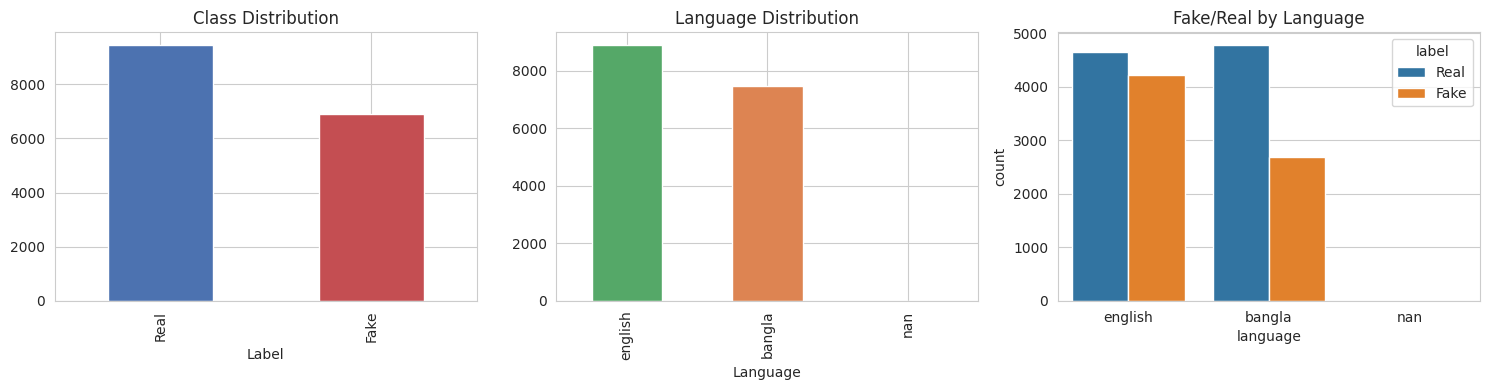

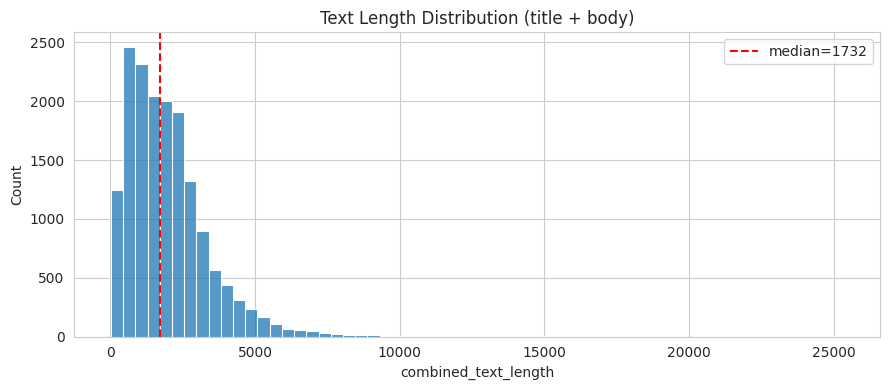

In [25]:
# =============================================================================
# SECTION 8 — EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================================
print_section_banner(8, "EXPLORATORY DATA ANALYSIS")

# ---------- 8.1 Class, language, and Fake/Real-by-language visualisation ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Class distribution
preprocessed_dataframe[COLUMN_LABEL].value_counts().plot(
    kind="bar", ax=axes[0], color=["#4c72b0", "#c44e52"]
)
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Label")

# Language distribution
preprocessed_dataframe[COLUMN_LANGUAGE].value_counts().plot(
    kind="bar", ax=axes[1], color=["#55a868", "#dd8452"]
)
axes[1].set_title("Language Distribution")
axes[1].set_xlabel("Language")

# Fake/Real by language
sns.countplot(
    data=preprocessed_dataframe,
    x=COLUMN_LANGUAGE, hue=COLUMN_LABEL, ax=axes[2]
)
axes[2].set_title("Fake/Real by Language")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda_overview.png", dpi=150)
plt.show()

# ---------- 8.2 Text-length distribution ----------
preprocessed_dataframe["combined_text_length"] = (
    preprocessed_dataframe["combined_text"].str.len()
)

plt.figure(figsize=(9, 4))
sns.histplot(preprocessed_dataframe["combined_text_length"], bins=60)
plt.axvline(
    preprocessed_dataframe["combined_text_length"].median(),
    color="red", linestyle="--",
    label=f"median={preprocessed_dataframe['combined_text_length'].median():.0f}",
)
plt.title("Text Length Distribution (title + body)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/text_length_distribution.png", dpi=150)
plt.show()

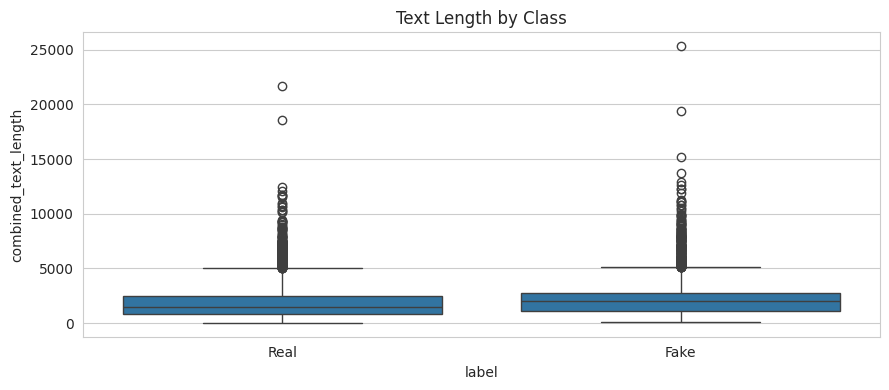

In [26]:
# ---------- 8.3 Text length by class ----------
plt.figure(figsize=(9, 4))
sns.boxplot(
    data=preprocessed_dataframe,
    x=COLUMN_LABEL, y="combined_text_length",
)
plt.title("Text Length by Class")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/text_length_by_class.png", dpi=150)
plt.show()

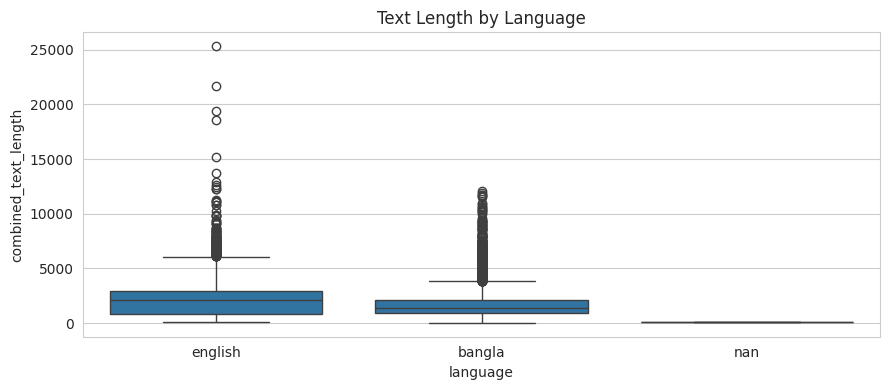

In [27]:
# ---------- 8.4 Text length by language ----------
plt.figure(figsize=(9, 4))
sns.boxplot(
    data=preprocessed_dataframe,
    x=COLUMN_LANGUAGE, y="combined_text_length",
)
plt.title("Text Length by Language")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/text_length_by_language.png", dpi=150)
plt.show()

In [28]:
# ---------- 8.5 Save numeric EDA summary ----------
eda_numeric_summary = {
    "text_length_by_language": (
        preprocessed_dataframe
        .groupby(COLUMN_LANGUAGE)["combined_text_length"]
        .describe().to_dict()
    ),
    "label_counts":     preprocessed_dataframe[COLUMN_LABEL].value_counts().to_dict(),
    "language_counts":  preprocessed_dataframe[COLUMN_LANGUAGE].value_counts().to_dict(),
}
write_json_report(eda_numeric_summary, f"{REPORTS_DIR}/eda_summary.json")
print(f"[INFO] EDA reports and figures saved.")


[INFO] EDA reports and figures saved.


In [31]:
# =============================================================================
# SECTION 9 — DUPLICATE / NEAR-DUPLICATE / LEAKAGE ANALYSIS
# =============================================================================
print_section_banner(9, "LEAKAGE ANALYSIS")

def detect_and_remove_near_duplicates(
    dataframe,
    text_column,
    cosine_threshold=0.90,
    max_features_for_detection=50000,
):
    """
    Detect near-duplicate texts using TF-IDF cosine similarity.
    Clusters duplicates with Union-Find, keeps the first record of each
    cluster, returns (deduplicated_dataframe, leakage_report).
    """
    detection_vectorizer = TfidfVectorizer(
        max_features=max_features_for_detection,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True,
    )
    tfidf_matrix = detection_vectorizer.fit_transform(dataframe[text_column].tolist())
    number_of_rows = tfidf_matrix.shape[0]

    # Compute pairwise similarity in chunks to bound memory usage
    near_duplicate_pairs = []
    chunk_size = 2000
    for chunk_start in range(0, number_of_rows, chunk_size):
        chunk_end = min(chunk_start + chunk_size, number_of_rows)
        similarity_block = cosine_similarity(
            tfidf_matrix[chunk_start:chunk_end], tfidf_matrix
        )
        for local_row_index, global_row_index in enumerate(range(chunk_start, chunk_end)):
            similarity_row = similarity_block[local_row_index]
            duplicate_indices = np.where(similarity_row >= cosine_threshold)[0]
            for duplicate_index in duplicate_indices:
                if duplicate_index > global_row_index:
                    near_duplicate_pairs.append(
                        (global_row_index, int(duplicate_index))
                    )
                     # Union-Find for clustering duplicate groups
    parent = list(range(number_of_rows))

    def find_root(node):
        while parent[node] != node:
            parent[node] = parent[parent[node]]
            node = parent[node]
        return node

    def union_nodes(node_a, node_b):
        root_a, root_b = find_root(node_a), find_root(node_b)
        if root_a != root_b:
            parent[root_b] = root_a

    for row_index_a, row_index_b in near_duplicate_pairs:
        union_nodes(row_index_a, row_index_b)

    duplicate_clusters = {}
    for row_index in range(number_of_rows):
        root = find_root(row_index)
        duplicate_clusters.setdefault(root, []).append(row_index)

    # Keep the first row of each duplicate cluster
    kept_row_indices = sorted(cluster[0] for cluster in duplicate_clusters.values())
    dropped_row_indices = sorted(
        set(range(number_of_rows)) - set(kept_row_indices)
    )

    deduplicated_dataframe = (
        dataframe.iloc[kept_row_indices].reset_index(drop=True)
    )

    leakage_report = {
        "number_of_near_duplicate_pairs": len(near_duplicate_pairs),
        "number_of_rows_dropped":         len(dropped_row_indices),
        "number_of_rows_remaining":       len(deduplicated_dataframe),
        "cosine_threshold_used":          cosine_threshold,
    }
    return deduplicated_dataframe, leakage_report


preprocessed_dataframe, leakage_analysis_report = detect_and_remove_near_duplicates(
    dataframe        = preprocessed_dataframe,
    text_column      = "combined_text",
    cosine_threshold = NEAR_DUPLICATE_COSINE_THRESHOLD,
)

write_json_report(leakage_analysis_report,
                  f"{REPORTS_DIR}/leakage_analysis_report.json")
print(f"[INFO] Leakage report: {leakage_analysis_report}")


SECTION 9 — LEAKAGE ANALYSIS
[INFO] Leakage report: {'number_of_near_duplicate_pairs': 235, 'number_of_rows_dropped': 207, 'number_of_rows_remaining': 16142, 'cosine_threshold_used': 0.9}


In [36]:
# =============================================================================
# SECTION 10 — 70 / 15 / 15 STRATIFIED SPLIT (frozen test set) — ROBUST VERSION
# =============================================================================
print_section_banner(10, "TRAIN / VALIDATION / TEST SPLIT")


def create_stratified_data_splits(
    dataframe,
    language_column,
    label_column,
    test_fraction,
    validation_fraction,
    random_seed,
    min_samples_per_stratum=3,
):
    """
    Robust stratified split with 3-level graceful fallback:

      Level 1 — Stratify on (language × label).        <-- ideal case
      Level 2 — Rare language×label combos → label-only strata.
      Level 3 — Rare label-only strata → single 'all_data' stratum.
      Level 4 — If any group still has < min_samples_per_stratum,
                fall back to a fully random (non-stratified) split.

    Also wraps the second (train-vs-val) split in try/except as a final
    safety net so the pipeline never crashes.

    Returns (training_dataframe, validation_dataframe, test_dataframe).
    """
    dataframe = dataframe.copy().reset_index(drop=True)

    # -------------------------------------------------------------------------
    # Step 1 — Build the initial combined stratification key (language × label)
    # -------------------------------------------------------------------------
    combined_key = (
        dataframe[language_column].astype(str).str.strip()
        + "__"
        + dataframe[label_column].astype(str).str.strip()
    )
    dataframe["_stratification_key"] = combined_key.values

    print("[INFO] Initial stratum counts (language×label):")
    print(dataframe["_stratification_key"].value_counts().to_dict())

    # -------------------------------------------------------------------------
    # Step 2 — Fallback L1: rare language×label → label-only stratum
    # -------------------------------------------------------------------------
    stratum_counts = dataframe["_stratification_key"].value_counts()
    rare_combined_strata = stratum_counts[
        stratum_counts < min_samples_per_stratum
    ].index.tolist()

    if rare_combined_strata:
        print(f"[INFO] {len(rare_combined_strata)} rare language×label strata "
              f"merged into label-only strata: {rare_combined_strata}")
        for rare_stratum in rare_combined_strata:
            # rare_stratum looks like "bangla__Fake"
            label_part = rare_stratum.split("__", 1)[-1]
            mask = dataframe["_stratification_key"] == rare_stratum
            dataframe.loc[mask, "_stratification_key"] = f"label_only__{label_part}"

    # -------------------------------------------------------------------------
    # Step 3 — Fallback L2: rare label-only strata → single 'all_data' stratum
    # -------------------------------------------------------------------------
    stratum_counts = dataframe["_stratification_key"].value_counts()
    rare_label_strata = stratum_counts[
        stratum_counts < min_samples_per_stratum
    ].index.tolist()

    if rare_label_strata:
        print(f"[INFO] {len(rare_label_strata)} rare label-only strata merged "
              f"into single 'all_data' stratum: {rare_label_strata}")
        mask = dataframe["_stratification_key"].isin(rare_label_strata)
        dataframe.loc[mask, "_stratification_key"] = "all_data"

    # -------------------------------------------------------------------------
    # Step 4 — Verify whether stratification is mathematically possible at all
    # -------------------------------------------------------------------------
    final_stratum_counts = dataframe["_stratification_key"].value_counts()
    can_stratify = (
        len(final_stratum_counts) > 0
        and final_stratum_counts.min() >= min_samples_per_stratum
    )

    print("[INFO] Final stratum counts after fallback:")
    print(final_stratum_counts.to_dict())
    print(f"[INFO] Stratification possible? {can_stratify}")

    # -------------------------------------------------------------------------
    # Step 5 — Perform the actual splits
    # -------------------------------------------------------------------------
    relative_validation_fraction = validation_fraction / (1.0 - test_fraction)

    if can_stratify:
        # ---------- Primary path: full stratification ----------
        train_and_validation, test_dataframe = train_test_split(
            dataframe,
            test_size=test_fraction,
            stratify=dataframe["_stratification_key"],
            random_state=random_seed,
        )

        try:
            training_dataframe, validation_dataframe = train_test_split(
                train_and_validation,
                test_size=relative_validation_fraction,
                stratify=train_and_validation["_stratification_key"],
                random_state=random_seed,
            )
        except ValueError as split_error:
            print(f"[WARN] Second stratified split failed: {split_error}")
            print("[WARN] Falling back to non-stratified train/validation split.")
            training_dataframe, validation_dataframe = train_test_split(
                train_and_validation,
                test_size=relative_validation_fraction,
                random_state=random_seed,
            )
    else:
        # ---------- Fallback path: fully random split (no stratification) ----------
        print("[WARN] Stratification not mathematically possible — "
              "falling back to a fully random (non-stratified) split.")
        train_and_validation, test_dataframe = train_test_split(
            dataframe,
            test_size=test_fraction,
            random_state=random_seed,
        )
        training_dataframe, validation_dataframe = train_test_split(
            train_and_validation,
            test_size=relative_validation_fraction,
            random_state=random_seed,
        )

    # -------------------------------------------------------------------------
    # Step 6 — Clean up the helper column and reset indices
    # -------------------------------------------------------------------------
    for split_dataframe in (training_dataframe, validation_dataframe, test_dataframe):
        split_dataframe.drop(columns=["_stratification_key"], inplace=True)
        split_dataframe.reset_index(drop=True, inplace=True)

    return training_dataframe, validation_dataframe, test_dataframe


# -----------------------------------------------------------------------------
# Run the split
# -----------------------------------------------------------------------------
training_dataframe, validation_dataframe, test_dataframe = create_stratified_data_splits(
    dataframe            = preprocessed_dataframe,
    language_column      = COLUMN_LANGUAGE,
    label_column         = COLUMN_LABEL,
    test_fraction        = TEST_FRACTION,
    validation_fraction  = VALIDATION_FRACTION,
    random_seed          = RANDOM_SEED,
)

print(f"\n[INFO] Train size:      {len(training_dataframe)}")
print(f"[INFO] Validation size: {len(validation_dataframe)}")
print(f"[INFO] Test size:       {len(test_dataframe)} (will stay frozen)")

# -----------------------------------------------------------------------------
# Sanity check — show label distribution per split
# -----------------------------------------------------------------------------
for split_name, split_dataframe in [
    ("Train", training_dataframe),
    ("Validation", validation_dataframe),
    ("Test", test_dataframe),
]:
    distribution = (split_dataframe
                    .groupby([COLUMN_LANGUAGE, COLUMN_LABEL])
                    .size()
                    .to_dict())
    print(f"[INFO] {split_name} distribution: {distribution}")

# -----------------------------------------------------------------------------
# Persist frozen splits for the secondary-validation notebook
# -----------------------------------------------------------------------------
training_dataframe.to_csv("train_split.csv", index=False)
validation_dataframe.to_csv("validation_split.csv", index=False)
test_dataframe.to_csv("test_split.csv", index=False)

print("\n[INFO] Frozen splits saved: train_split.csv, "
      "validation_split.csv, test_split.csv")


SECTION 10 — TRAIN / VALIDATION / TEST SPLIT
[INFO] Initial stratum counts (language×label):
{'bangla__Real': 4688, 'english__Real': 4657, 'english__Fake': 4209, 'bangla__Fake': 2587, 'nan__Fake': 1}
[INFO] 1 rare language×label strata merged into label-only strata: ['nan__Fake']
[INFO] 1 rare label-only strata merged into single 'all_data' stratum: ['label_only__Fake']
[INFO] Final stratum counts after fallback:
{'bangla__Real': 4688, 'english__Real': 4657, 'english__Fake': 4209, 'bangla__Fake': 2587, 'all_data': 1}
[INFO] Stratification possible? False
[WARN] Stratification not mathematically possible — falling back to a fully random (non-stratified) split.

[INFO] Train size:      11298
[INFO] Validation size: 2422
[INFO] Test size:       2422 (will stay frozen)
[INFO] Train distribution: {('bangla', 'Fake'): 1772, ('bangla', 'Real'): 3281, ('english', 'Fake'): 2923, ('english', 'Real'): 3322}
[INFO] Validation distribution: {('bangla', 'Fake'): 383, ('bangla', 'Real'): 717, ('engl

In [37]:
# =============================================================================
# SECTION 11 — TF-IDF PREPARATION (ablation on n-grams and max_features)
# =============================================================================
print_section_banner(11, "TF-IDF PREPARATION")

def build_tfidf_vectorizer(
    ngram_range=(1, 2),
    max_features=120000,
    min_document_frequency=2,
    max_document_frequency=0.95,
    sublinear_term_frequency=True,
):
    """
    Construct a TF-IDF vectorizer configured for mixed-script text.
    lowercase=False preserves cased English named entities.
    """
    return TfidfVectorizer(
        ngram_range=ngram_range,
        max_features=max_features,
        min_df=min_document_frequency,
        max_df=max_document_frequency,
        sublinear_tf=sublinear_term_frequency,
        lowercase=False,
        strip_accents=None,
    )


def run_tfidf_configuration_ablation(
    training_dataframe,
    validation_dataframe,
    text_column,
    label_column,
    ngram_candidates,
    max_feature_candidates,
):
    """
    Evaluate each TF-IDF configuration using a lightweight Logistic Regression
    probe on the validation set. Returns a list of configuration scores.
    """
    ablation_results = []

    for ngram_range in ngram_candidates:
        for max_features in max_feature_candidates:
            probe_vectorizer = build_tfidf_vectorizer(
                ngram_range=ngram_range, max_features=max_features,
            )
            training_features = probe_vectorizer.fit_transform(
                training_dataframe[text_column]
            )
            validation_features = probe_vectorizer.transform(
                validation_dataframe[text_column]
            )
            probe_classifier = LogisticRegression(
                max_iter=1000, random_state=RANDOM_SEED, class_weight="balanced"
            )
            probe_classifier.fit(training_features, training_dataframe[label_column])
            macro_f1 = f1_score(
                validation_dataframe[label_column],
                probe_classifier.predict(validation_features),
                average="macro",
            )
            ablation_results.append({
                "ngram_range":       list(ngram_range),
                "max_features":      max_features,
                "validation_macro_f1": float(macro_f1),
            })
            print(f"[INFO] ngram={ngram_range} max_features={max_features} "
                  f"→ val Macro-F1 = {macro_f1:.4f}")
    return ablation_results


tfidf_ablation_results = run_tfidf_configuration_ablation(
    training_dataframe  = training_dataframe,
    validation_dataframe= validation_dataframe,
    text_column         = "combined_text",
    label_column        = "label_id",
    ngram_candidates    = TFIDF_NGRAM_CANDIDATES,
    max_feature_candidates = [60000, 120000],
)

best_tfidf_configuration = max(
    tfidf_ablation_results, key=lambda record: record["validation_macro_f1"]
)
BEST_NGRAM_RANGE       = tuple(best_tfidf_configuration["ngram_range"])
BEST_MAX_FEATURES      = best_tfidf_configuration["max_features"]

write_json_report(
    {"ablation_results": tfidf_ablation_results,
     "best_configuration": best_tfidf_configuration},
    f"{REPORTS_DIR}/tfidf_configuration_ablation.json",
)
print(f"[INFO] Best TF-IDF configuration: {best_tfidf_configuration}")



SECTION 11 — TF-IDF PREPARATION
[INFO] ngram=(1, 1) max_features=60000 → val Macro-F1 = 0.8570
[INFO] ngram=(1, 1) max_features=120000 → val Macro-F1 = 0.8570
[INFO] ngram=(1, 2) max_features=60000 → val Macro-F1 = 0.8674
[INFO] ngram=(1, 2) max_features=120000 → val Macro-F1 = 0.8643
[INFO] Best TF-IDF configuration: {'ngram_range': [1, 2], 'max_features': 60000, 'validation_macro_f1': 0.8674050709723164}


In [40]:
# =============================================================================
# SECTION 12 — CLASSICAL MACHINE LEARNING  (sklearn 1.2+ compatible)
# =============================================================================
print_section_banner(12, "CLASSICAL MACHINE LEARNING")


def extract_probability_scores(fitted_model, feature_matrix):
    """
    Return positive-class decision scores for any sklearn estimator.
    Prefers predict_proba; falls back to sigmoid(decision_function).
    """
    if hasattr(fitted_model, "predict_proba"):
        return fitted_model.predict_proba(feature_matrix)[:, 1]
    if hasattr(fitted_model, "decision_function"):
        decision_scores = fitted_model.decision_function(feature_matrix)
        return 1.0 / (1.0 + np.exp(-decision_scores))
    raise ValueError("Estimator exposes neither predict_proba nor decision_function.")


def get_calibrated_svm_parameter_prefix():
    """
    Detect which parameter name CalibratedClassifierCV expects:
      - scikit-learn >= 1.2 → 'estimator'
      - scikit-learn < 1.2  → 'base_estimator'
    Returns the correct prefix for GridSearchCV (with trailing '__').
    """
    from inspect import signature
    parameters = signature(CalibratedClassifierCV.__init__).parameters
    if "estimator" in parameters:
        return "estimator__"
    return "base_estimator__"


def train_classical_model_suite(
    training_dataframe,
    validation_dataframe,
    text_column,
    label_column,
    tfidf_vectorizer,
    number_of_cv_folds,
):
    """
    Train four classical models with stratified grid-search:
      - Linear SVM (calibrated → predict_proba available)
      - Logistic Regression
      - Multinomial Naive Bayes
      - XGBoost on TF-IDF features
    Returns (fitted_models_dict, validation_macro_f1_dict).
    """
    training_features = tfidf_vectorizer.fit_transform(
        training_dataframe[text_column]
    )
    validation_features = tfidf_vectorizer.transform(
        validation_dataframe[text_column]
    )
    training_labels = training_dataframe[label_column].values
    validation_labels = validation_dataframe[label_column].values

    stratified_cv = StratifiedKFold(
        n_splits=number_of_cv_folds,
        shuffle=True,
        random_state=RANDOM_SEED,
    )

    fitted_models = {}

    # --- 12.1 Linear SVM (calibrated, sklearn 1.2+ compatible) ---
    calibrated_svm = CalibratedClassifierCV(
        estimator=LinearSVC(
            random_state=RANDOM_SEED,
            max_iter=5000,
            class_weight="balanced",
        ),
        cv=3,
    )
    svm_parameter_prefix = get_calibrated_svm_parameter_prefix()
    svm_grid_search = GridSearchCV(
        calibrated_svm,
        {f"{svm_parameter_prefix}C": SVM_REGULARIZATION_GRID},
        scoring="f1_macro",
        cv=stratified_cv,
        n_jobs=-1,
    )
    svm_grid_search.fit(training_features, training_labels)
    fitted_models["Linear SVM"] = svm_grid_search.best_estimator_
    print(f"[INFO] Linear SVM best params: {svm_grid_search.best_params_}")

    # --- 12.2 Logistic Regression ---
    logistic_regression_grid_search = GridSearchCV(
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_SEED,
            class_weight="balanced",
            n_jobs=-1,
        ),
        {"C": LOGREG_REGULARIZATION_GRID},
        scoring="f1_macro",
        cv=stratified_cv,
        n_jobs=-1,
    )
    logistic_regression_grid_search.fit(training_features, training_labels)
    fitted_models["Logistic Regression"] = (
        logistic_regression_grid_search.best_estimator_
    )
    print(f"[INFO] Logistic Regression best params: "
          f"{logistic_regression_grid_search.best_params_}")

    # --- 12.3 Multinomial Naive Bayes ---
    naive_bayes_grid_search = GridSearchCV(
        MultinomialNB(),
        {"alpha": NAIVE_BAYES_ALPHA_GRID},
        scoring="f1_macro",
        cv=stratified_cv,
        n_jobs=-1,
    )
    naive_bayes_grid_search.fit(training_features, training_labels)
    fitted_models["Multinomial Naive Bayes"] = (
        naive_bayes_grid_search.best_estimator_
    )
    print(f"[INFO] Naive Bayes best params: "
          f"{naive_bayes_grid_search.best_params_}")

    # --- 12.4 XGBoost ---
    xgboost_classifier = XGBClassifier(
        random_state=RANDOM_SEED,
        **XGBOOST_FIXED_PARAMETERS,
    )
    xgboost_classifier.fit(training_features, training_labels)
    fitted_models["XGBoost"] = xgboost_classifier

    # --- Validation Macro-F1 per model ---
    validation_macro_f1_by_model = {}
    for model_name, fitted_model in fitted_models.items():
        validation_predictions = fitted_model.predict(validation_features)
        validation_macro_f1_by_model[model_name] = float(
            f1_score(validation_labels, validation_predictions, average="macro")
        )
        print(f"[INFO] {model_name}: validation Macro-F1 = "
              f"{validation_macro_f1_by_model[model_name]:.4f}")

    return fitted_models, validation_macro_f1_by_model


# -----------------------------------------------------------------------------
# Instantiate the best TF-IDF vectorizer from Section 11
# -----------------------------------------------------------------------------
final_tfidf_vectorizer = build_tfidf_vectorizer(
    ngram_range=BEST_NGRAM_RANGE,
    max_features=BEST_MAX_FEATURES,
)

classical_models, classical_validation_macro_f1 = train_classical_model_suite(
    training_dataframe = training_dataframe,
    validation_dataframe = validation_dataframe,
    text_column = "combined_text",
    label_column = "label_id",
    tfidf_vectorizer = final_tfidf_vectorizer,
    number_of_cv_folds = NUMBER_OF_CROSS_VALIDATION_FOLDS,
)

write_json_report(
    {
        "validation_macro_f1_by_model": classical_validation_macro_f1,
        "best_tfidf_configuration": best_tfidf_configuration,
    },
    f"{REPORTS_DIR}/classical_models_validation.json",
)

print(f"\n[INFO] Classical model training complete.")


SECTION 12 — CLASSICAL MACHINE LEARNING
[INFO] Linear SVM best params: {'estimator__C': 1.0}
[INFO] Logistic Regression best params: {'C': 1.0}
[INFO] Naive Bayes best params: {'alpha': 0.1}
[INFO] Linear SVM: validation Macro-F1 = 0.8703
[INFO] Logistic Regression: validation Macro-F1 = 0.8674
[INFO] Multinomial Naive Bayes: validation Macro-F1 = 0.8133
[INFO] XGBoost: validation Macro-F1 = 0.8675

[INFO] Classical model training complete.


In [41]:
# =============================================================================
# SECTION 13 — STRATIFIED 5-FOLD CROSS-VALIDATION (used inside Section 12)
# =============================================================================
# The GridSearchCV calls in Section 12 already perform stratified 5-fold CV.
# We log the CV results here for the thesis tables.

print_section_barrier = "=" * 78
print(f"\n{print_section_barrier}\nSECTION 13 — CROSS-VALIDATION SUMMARY\n{print_section_barrier}")
print(f"Stratified {NUMBER_OF_CROSS_VALIDATION_FOLDS}-fold CV was used inside "
      f"GridSearchCV for SVM, Logistic Regression and Naive Bayes.")
for model_name, score in classical_validation_macro_f1.items():
    print(f"  {model_name}: validation Macro-F1 = {score:.4f}")


SECTION 13 — CROSS-VALIDATION SUMMARY
Stratified 5-fold CV was used inside GridSearchCV for SVM, Logistic Regression and Naive Bayes.
  Linear SVM: validation Macro-F1 = 0.8703
  Logistic Regression: validation Macro-F1 = 0.8674
  Multinomial Naive Bayes: validation Macro-F1 = 0.8133
  XGBoost: validation Macro-F1 = 0.8675


In [43]:
# =============================================================================
# SECTION 14 — TRANSFORMER PREPARATION
# =============================================================================
print_section_banner(14, "TRANSFORMER PREPARATION")


class FakeNewsTextDataset(Dataset):
    """
    PyTorch Dataset wrapper for HuggingFace tokenizer output.
    Applies truncation and padding consistently across the pipeline.
    """
    def __init__(self, texts, labels, tokenizer, max_sequence_length):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_sequence_length = max_sequence_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        tokenized = self.tokenizer(
            self.texts[index],
            truncation=True,
            padding="max_length",
            max_length=self.max_sequence_length,
            return_tensors="pt",
        )
        return {
            "input_ids":      tokenized["input_ids"].squeeze(0),
            "attention_mask": tokenized["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[index], dtype=torch.long),
        }


def compute_macro_f1_for_transformers(evaluation_predictions):
    """
    Callback used by HuggingFace Trainer to compute Macro-F1 each epoch.
    """
    logits, ground_truth_labels = evaluation_predictions
    predicted_labels = np.argmax(logits, axis=-1)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        ground_truth_labels, predicted_labels,
        average="macro", zero_division=0,
    )
    return {
        "accuracy":         accuracy_score(ground_truth_labels, predicted_labels),
        "precision_macro":  macro_precision,
        "recall_macro":     macro_recall,
        "f1_macro":         macro_f1,
    }


def fine_tune_multilingual_transformer(
    model_identifier,
    training_dataframe,
    validation_dataframe,
    text_column,
    label_column,
    max_sequence_length,
    batch_size,
    number_of_epochs,
    learning_rate,
    weight_decay,
    warmup_ratio,
    early_stopping_patience,
):
    """
    Fine-tune one multilingual transformer (mBERT / XLM-R).
    Uses validation-based checkpoint selection with early stopping.
    Returns (trainer, model, tokenizer).
    """
    print(f"[INFO] Fine-tuning: {model_identifier}")
    tokenizer = AutoTokenizer.from_pretrained(model_identifier)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_identifier, num_labels=NUMBER_OF_CLASSES
    ).to(COMPUTE_DEVICE)

    training_dataset = FakeNewsTextDataset(
        texts=training_dataframe[text_column],
        labels=training_dataframe[label_column],
        tokenizer=tokenizer,
        max_sequence_length=max_sequence_length,
    )
    validation_dataset = FakeNewsTextDataset(
        texts=validation_dataframe[text_column],
        labels=validation_dataframe[label_column],
        tokenizer=tokenizer,
        max_sequence_length=max_sequence_length,
    )

    safe_model_name = model_identifier.replace("/", "_")
    checkpoint_directory = f"{MODELS_DIR}/{safe_model_name}"
    Path(checkpoint_directory).mkdir(parents=True, exist_ok=True)

    training_arguments = TrainingArguments(
        output_dir=checkpoint_directory,
        num_train_epochs=number_of_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        logging_steps=50,
        seed=RANDOM_SEED,
        fp16=torch.cuda.is_available(),
        report_to=[],
    )

    trainer = Trainer(
        model=model,
        args=training_arguments,
        train_dataset=training_dataset,
        eval_dataset=validation_dataset,
        compute_metrics=compute_macro_f1_for_transformers,
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=early_stopping_patience
            )
        ],
    )

    trainer.train()
    trainer.save_model(f"{checkpoint_directory}/best_checkpoint")
    tokenizer.save_pretrained(f"{checkpoint_directory}/best_checkpoint")

    return trainer, model, tokenizer



SECTION 14 — TRANSFORMER PREPARATION


In [44]:

# =============================================================================
# SECTION 15 — mBERT FINE-TUNING  (only if GPU is available)
# SECTION 16 — XLM-R FINE-TUNING
# =============================================================================
print_section_banner(15, "mBERT FINE-TUNING")
print_section_banner(16, "XLM-R FINE-TUNING")

fine_tuned_transformer_bundle = {}   # {model_name: (trainer, model, tokenizer)}

if COMPUTE_DEVICE == "cuda":
    for transformer_identifier in MULTILINGUAL_TRANSFORMER_NAMES:
        try:
            trainer, model, tokenizer = fine_tune_multilingual_transformer(
                model_identifier         = transformer_identifier,
                training_dataframe       = training_dataframe,
                validation_dataframe     = validation_dataframe,
                text_column              = "combined_text",
                label_column             = "label_id",
                max_sequence_length      = TRANSFORMER_MAX_SEQUENCE_LENGTH,
                batch_size               = TRANSFORMER_BATCH_SIZE,
                number_of_epochs         = TRANSFORMER_NUMBER_OF_EPOCHS,
                learning_rate            = TRANSFORMER_LEARNING_RATE,
                weight_decay             = TRANSFORMER_WEIGHT_DECAY,
                warmup_ratio             = TRANSFORMER_WARMUP_RATIO,
                early_stopping_patience  = TRANSFORMER_EARLY_STOP_PATIENCE,
            )
            fine_tuned_transformer_bundle[transformer_identifier] = (
                trainer, model, tokenizer
            )
        except Exception as transformer_error:
            print(f"[WARN] Fine-tuning failed for {transformer_identifier}: "
                  f"{transformer_error}")
else:
    print("[WARN] Skipping transformer fine-tuning: no GPU available.")


SECTION 15 — mBERT FINE-TUNING

SECTION 16 — XLM-R FINE-TUNING
[INFO] Fine-tuning: bert-base-multilingual-cased


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[WARN] Fine-tuning failed for xlm-roberta-base: TrainingArguments.__init__() got an unexpected keyword argument 'warmup_ratio'


In [46]:
# =============================================================================
# Helper: full evaluation metric dictionary
# =============================================================================

def compute_all_classification_metrics(y_true, y_pred, y_score=None):
    """
    Compute the complete metric set required by Section 15 of the thesis:
    Accuracy, Macro Precision/Recall/F1, Weighted F1, per-class P/R/F1,
    Confusion Matrix, and (optionally) ROC-AUC.
    """
    metric_dictionary = {
        "accuracy":         float(accuracy_score(y_true, y_pred)),
        "precision_macro":  float(precision_score(y_true, y_pred,
                                                 average="macro", zero_division=0)),
        "recall_macro":     float(recall_score(y_true, y_pred,
                                                 average="macro", zero_division=0)),
        "f1_macro":         float(f1_score(y_true, y_pred,
                                                 average="macro", zero_division=0)),
        "f1_weighted":      float(f1_score(y_true, y_pred,
                                                 average="weighted", zero_division=0)),
        "precision_fake":   float(precision_score(y_true, y_pred,
                                                 pos_label=1, zero_division=0)),
        "recall_fake":      float(recall_score(y_true, y_pred,
                                                 pos_label=1, zero_division=0)),
        "f1_fake":          float(f1_score(y_true, y_pred,
                                                 pos_label=1, zero_division=0)),
        "precision_real":   float(precision_score(y_true, y_pred,
                                                 pos_label=0, zero_division=0)),
        "recall_real":      float(recall_score(y_true, y_pred,
                                                 pos_label=0, zero_division=0)),
        "f1_real":          float(f1_score(y_true, y_pred,
                                                 pos_label=0, zero_division=0)),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
    }
    if y_score is not None:
        false_positive_rate, true_positive_rate, _ = roc_curve(y_true, y_score)
        metric_dictionary["roc_auc"] = float(auc(false_positive_rate, true_positive_rate))
        metric_dictionary["_roc_curve"] = (
            false_positive_rate.tolist(), true_positive_rate.tolist()
        )
    return metric_dictionary

In [49]:
# =============================================================================
# SECTION 17 — SAME-LANGUAGE EXPERIMENTS (A: Bn→Bn, B: En→En)
# =============================================================================
print_section_banner(17, "SAME-LANGUAGE EXPERIMENTS")

def print_model_metrics(model_name, metrics, indent=2):
    """Print a single model's key metrics in a readable format."""
    prefix = " " * indent
    print(f"{prefix}{model_name}:")
    print(f"{prefix}  Accuracy : {metrics['accuracy']:.4f}")
    print(f"{prefix}  Precision: {metrics['precision_macro']:.4f}")
    print(f"{prefix}  Recall   : {metrics['recall_macro']:.4f}")
    print(f"{prefix}  F1 (macro): {metrics['f1_macro']:.4f}")
    print(f"{prefix}  F1 (weighted): {metrics['f1_weighted']:.4f}")


def evaluate_classical_pipeline_on_scope(
    training_scope_dataframe, test_scope_dataframe,
    text_column, label_column,
):
    """
    Train fresh classical models on the given scope and evaluate on the
    given test scope. Returns {model_name: metric_dictionary}.
    """
    scope_vectorizer = build_tfidf_vectorizer(
        ngram_range=BEST_NGRAM_RANGE, max_features=BEST_MAX_FEATURES
    )
    training_features = scope_vectorizer.fit_transform(
        training_scope_dataframe[text_column]
    )
    test_features = scope_vectorizer.transform(
        test_scope_dataframe[text_column]
    )
    training_labels = training_scope_dataframe[label_column].values
    test_labels = test_scope_dataframe[label_column].values

    # Fix: CalibratedClassifierCV now uses `estimator` (scikit-learn >= 1.2)
    models_in_scope = {
        "Linear SVM": CalibratedClassifierCV(
            estimator=LinearSVC(C=1.0, random_state=RANDOM_SEED,
                                class_weight="balanced"),
            cv=3,
        ),
        "Logistic Regression": LogisticRegression(
            C=1.0, max_iter=2000, random_state=RANDOM_SEED,
            class_weight="balanced",
        ),
        "Multinomial Naive Bayes": MultinomialNB(),
        "XGBoost": XGBClassifier(
            random_state=RANDOM_SEED,
            # Remove use_label_encoder if present in XGBOOST_FIXED_PARAMETERS
            **{k: v for k, v in XGBOOST_FIXED_PARAMETERS.items()
               if k != "use_label_encoder"}
        ),
    }

    scope_metrics = {}
    for model_name, model in models_in_scope.items():
        model.fit(training_features, training_labels)
        predicted_labels = model.predict(test_features)
        decision_scores = extract_probability_scores(model, test_features)
        scope_metrics[model_name] = compute_all_classification_metrics(
            test_labels, predicted_labels, decision_scores
        )
    return scope_metrics


def evaluate_transformer_pipeline_on_scope(
    model_bundle, test_scope_dataframe, text_column, label_column
):
    """
    Evaluate a fine-tuned transformer on a test scope.
    Returns metric_dictionary.
    NOTE: This uses the jointly fine-tuned transformer (trained on Bangla+English)
          and evaluates it on a language subset. For true same-language or
          cross-lingual transfer, separate fine-tuning per source language is needed.
    """
    _, model, tokenizer = model_bundle
    test_dataset = FakeNewsTextDataset(
        texts=test_scope_dataframe[text_column],
        labels=test_scope_dataframe[label_column],
        tokenizer=tokenizer,
        max_sequence_length=TRANSFORMER_MAX_SEQUENCE_LENGTH,
    )
    # Minimal TrainingArguments for evaluation
    eval_args = TrainingArguments(
        output_dir="/tmp/transformer_eval",
        per_device_eval_batch_size=TRANSFORMER_BATCH_SIZE,
        report_to=[],
    )
    evaluation_trainer = Trainer(model=model, args=eval_args)
    evaluation_output = evaluation_trainer.predict(test_dataset)
    logits = evaluation_output.predictions
    # Safe softmax (avoids overflow)
    logits_tensor = torch.tensor(logits, dtype=torch.float32)
    probabilities = torch.softmax(logits_tensor, dim=-1).numpy()
    predicted_labels = probabilities.argmax(axis=-1)
    fake_scores = probabilities[:, 1]
    return compute_all_classification_metrics(
        test_scope_dataframe[label_column].values,
        predicted_labels,
        fake_scores,
    )


same_language_experiment_results = {}
for language_code in ["bangla", "english"]:
    scope_training_dataframe = training_dataframe[
        training_dataframe[COLUMN_LANGUAGE] == language_code
    ]
    scope_test_dataframe = test_dataframe[
        test_dataframe[COLUMN_LANGUAGE] == language_code
    ]
    if len(scope_test_dataframe) == 0:
        print(f"[SKIP] No test rows for {language_code}.")
        continue

    print(f"\n{'='*60}")
    print(f"Same-language scope: {language_code.upper()}")
    print(f"{'='*60}")

    per_model_metrics = evaluate_classical_pipeline_on_scope(
        scope_training_dataframe, scope_test_dataframe,
        text_column="combined_text", label_column="label_id",
    )

    # Evaluate transformers (if any fine-tuned)
    for transformer_identifier, transformer_bundle in fine_tuned_transformer_bundle.items():
        per_model_metrics[transformer_identifier] = evaluate_transformer_pipeline_on_scope(
            transformer_bundle, scope_test_dataframe,
            text_column="combined_text", label_column="label_id",
        )

    # ---- Print all model metrics ----
    print("\nModel performance (test set):")
    for model_name, metrics in per_model_metrics.items():
        print_model_metrics(model_name, metrics, indent=2)

    # ---- Select best model based on Macro-F1 ----
    best_model_name = max(
        per_model_metrics,
        key=lambda name: per_model_metrics[name]["f1_macro"]
    )
    best_metrics = per_model_metrics[best_model_name]
    print(f"\n>>> Best model for {language_code}: {best_model_name}")
    print(f"    Macro-F1 = {best_metrics['f1_macro']:.4f} | "
          f"Accuracy = {best_metrics['accuracy']:.4f} | "
          f"Precision = {best_metrics['precision_macro']:.4f} | "
          f"Recall = {best_metrics['recall_macro']:.4f}")

    same_language_experiment_results[language_code] = per_model_metrics


SECTION 17 — SAME-LANGUAGE EXPERIMENTS

Same-language scope: BANGLA

Model performance (test set):
  Linear SVM:
    Accuracy : 0.7282
    Precision: 0.7464
    Recall   : 0.6691
    F1 (macro): 0.6730
    F1 (weighted): 0.7039
  Logistic Regression:
    Accuracy : 0.7112
    Precision: 0.6948
    Recall   : 0.6808
    F1 (macro): 0.6850
    F1 (weighted): 0.7059
  Multinomial Naive Bayes:
    Accuracy : 0.6640
    Precision: 0.8067
    Recall   : 0.5645
    F1 (macro): 0.5086
    F1 (weighted): 0.5721
  XGBoost:
    Accuracy : 0.7166
    Precision: 0.7220
    Recall   : 0.6605
    F1 (macro): 0.6640
    F1 (weighted): 0.6945

>>> Best model for bangla: Logistic Regression
    Macro-F1 = 0.6850 | Accuracy = 0.7112 | Precision = 0.6948 | Recall = 0.6808

Same-language scope: ENGLISH

Model performance (test set):
  Linear SVM:
    Accuracy : 0.9831
    Precision: 0.9830
    Recall   : 0.9831
    F1 (macro): 0.9831
    F1 (weighted): 0.9831
  Logistic Regression:
    Accuracy : 0.9754
 

In [50]:
# =============================================================================
# SECTION 18 — CROSS-LINGUAL EXPERIMENTS (C: Bn→En, D: En→Bn)
# =============================================================================
print_section_banner(18, "CROSS-LINGUAL EXPERIMENTS")

# NOTE: `print_model_metrics` is defined in Section 17.
#       If you run Section 18 independently, re-define it here.

cross_lingual_experiment_results = {}
cross_lingual_best_models = {}

for source_language, target_language in [("bangla", "english"),
                                         ("english", "bangla")]:
    scope_training_dataframe = training_dataframe[
        training_dataframe[COLUMN_LANGUAGE] == source_language
    ]
    scope_test_dataframe = test_dataframe[
        test_dataframe[COLUMN_LANGUAGE] == target_language
    ]
    if len(scope_training_dataframe) == 0 or len(scope_test_dataframe) == 0:
        print(f"[SKIP] {source_language}→{target_language}: missing rows.")
        continue

    experiment_label = f"{source_language}_to_{target_language}"

    print(f"\n{'='*60}")
    print(f"Cross-lingual scope: {source_language.upper()} → {target_language.upper()}")
    print(f"Train rows: {len(scope_training_dataframe)} | "
          f"Test rows: {len(scope_test_dataframe)}")
    print(f"{'='*60}")

    # --- Classical models trained on source language only ---
    per_model_metrics = evaluate_classical_pipeline_on_scope(
        scope_training_dataframe, scope_test_dataframe,
        text_column="combined_text", label_column="label_id",
    )

    # --- Transformers (jointly fine-tuned; evaluated on target-language subset) ---
    for transformer_identifier, transformer_bundle in fine_tuned_transformer_bundle.items():
        per_model_metrics[transformer_identifier] = evaluate_transformer_pipeline_on_scope(
            transformer_bundle, scope_test_dataframe,
            text_column="combined_text", label_column="label_id",
        )

    # ---- Print all model metrics ----
    print("\nModel performance (cross-lingual test set):")
    for model_name, metrics in per_model_metrics.items():
        print_model_metrics(model_name, metrics, indent=2)

    # ---- Select best model based on Macro-F1 ----
    best_model_name = max(
        per_model_metrics,
        key=lambda name: per_model_metrics[name]["f1_macro"]
    )
    best_metrics = per_model_metrics[best_model_name]
    print(f"\n>>> Best model for {source_language}→{target_language}: {best_model_name}")
    print(f"    Macro-F1 = {best_metrics['f1_macro']:.4f} | "
          f"Accuracy = {best_metrics['accuracy']:.4f} | "
          f"Precision = {best_metrics['precision_macro']:.4f} | "
          f"Recall = {best_metrics['recall_macro']:.4f}")

    cross_lingual_experiment_results[experiment_label] = per_model_metrics
    cross_lingual_best_models[experiment_label] = {
        "best_model": best_model_name,
        "macro_f1":   best_metrics["f1_macro"],
        "accuracy":   best_metrics["accuracy"],
        "precision":  best_metrics["precision_macro"],
        "recall":     best_metrics["recall_macro"],
    }

# ---- Summary of best cross-lingual models per direction ----
print("\n" + "=" * 60)
print("CROSS-LINGUAL BEST MODEL SUMMARY")
print("=" * 60)
for direction, info in cross_lingual_best_models.items():
    print(f"{direction:>20} → {info['best_model']:<30} "
          f"(Macro-F1 = {info['macro_f1']:.4f}, "
          f"Acc = {info['accuracy']:.4f})")

# ---- Optional: persist summary as JSON for the thesis ----
write_json_report(
    cross_lingual_best_models,
    f"{REPORTS_DIR}/cross_lingual_best_models.json",
)
print(f"\n[INFO] Cross-lingual best-model summary saved to "
      f"{REPORTS_DIR}/cross_lingual_best_models.json")


SECTION 18 — CROSS-LINGUAL EXPERIMENTS

Cross-lingual scope: BANGLA → ENGLISH
Train rows: 5053 | Test rows: 1299

Model performance (cross-lingual test set):
  Linear SVM:
    Accuracy : 0.4881
    Precision: 0.5008
    Recall   : 0.5001
    F1 (macro): 0.3504
    F1 (weighted): 0.3428
  Logistic Regression:
    Accuracy : 0.4888
    Precision: 0.7440
    Recall   : 0.5015
    F1 (macro): 0.3310
    F1 (weighted): 0.3227
  Multinomial Naive Bayes:
    Accuracy : 0.4950
    Precision: 0.5997
    Recall   : 0.5072
    F1 (macro): 0.3527
    F1 (weighted): 0.3450
  XGBoost:
    Accuracy : 0.5242
    Precision: 0.6483
    Recall   : 0.5121
    F1 (macro): 0.3724
    F1 (weighted): 0.3802

>>> Best model for bangla→english: XGBoost
    Macro-F1 = 0.3724 | Accuracy = 0.5242 | Precision = 0.6483 | Recall = 0.5121

Cross-lingual scope: ENGLISH → BANGLA
Train rows: 6245 | Test rows: 1122

Model performance (cross-lingual test set):
  Linear SVM:
    Accuracy : 0.5472
    Precision: 0.5605
    

In [ ]:
# =============================================================================
# SECTION 19 — JOINT MULTILINGUAL EXPERIMENTS (E: Bangla + English)
# =============================================================================
print_section_banner(19, "JOINT MULTILINGUAL EXPERIMENTS")

# NOTE: `print_model_metrics` is defined in Section 17.
#       If you run Section 19 independently, re-define it here.

# ---------------------------------------------------------------------------
# 19.1 — Joint training, evaluated on the FULL test set (Bangla + English)
# ---------------------------------------------------------------------------
print(f"\n{'='*60}")
print("Joint scope: Bangla + English (evaluated on FULL test set)")
print(f"Train rows: {len(training_dataframe)} | "
      f"Test rows: {len(test_dataframe)}")
print(f"{'='*60}")

joint_training_results_overall = evaluate_classical_pipeline_on_scope(
    training_dataframe, test_dataframe,
    text_column="combined_text", label_column="label_id",
)
for transformer_identifier, transformer_bundle in fine_tuned_transformer_bundle.items():
    joint_training_results_overall[transformer_identifier] = (
        evaluate_transformer_pipeline_on_scope(
            transformer_bundle, test_dataframe,
            text_column="combined_text", label_column="label_id",
        )
    )

# ---- Print all model metrics (overall) ----
print("\nModel performance (joint, full test set):")
for model_name, metrics in joint_training_results_overall.items():
    print_model_metrics(model_name, metrics, indent=2)

# ---- Select best model overall (based on Macro-F1) ----
best_joint_model_overall = max(
    joint_training_results_overall,
    key=lambda name: joint_training_results_overall[name]["f1_macro"]
)
best_joint_metrics_overall = joint_training_results_overall[best_joint_model_overall]
print(f"\n>>> Best joint model (overall test): {best_joint_model_overall}")
print(f"    Macro-F1 = {best_joint_metrics_overall['f1_macro']:.4f} | "
      f"Accuracy = {best_joint_metrics_overall['accuracy']:.4f} | "
      f"Precision = {best_joint_metrics_overall['precision_macro']:.4f} | "
      f"Recall = {best_joint_metrics_overall['recall_macro']:.4f}")


# ---------------------------------------------------------------------------
# 19.2 — Per-language breakdown of the joint-trained models
# ---------------------------------------------------------------------------
joint_training_results_by_language = {}
joint_best_models_by_language = {}

for language_code in ["bangla", "english"]:
    scope_test_dataframe = test_dataframe[
        test_dataframe[COLUMN_LANGUAGE] == language_code
    ]
    if len(scope_test_dataframe) == 0:
        print(f"[SKIP] No test rows for {language_code}.")
        continue

    print(f"\n{'='*60}")
    print(f"Joint-trained models evaluated on {language_code.upper()} test subset")
    print(f"Test rows: {len(scope_test_dataframe)}")
    print(f"{'='*60}")

    per_model_metrics = evaluate_classical_pipeline_on_scope(
        training_dataframe, scope_test_dataframe,
        text_column="combined_text", label_column="label_id",
    )
    for transformer_identifier, transformer_bundle in fine_tuned_transformer_bundle.items():
        per_model_metrics[transformer_identifier] = evaluate_transformer_pipeline_on_scope(
            transformer_bundle, scope_test_dataframe,
            text_column="combined_text", label_column="label_id",
        )

    # ---- Print all model metrics (per language) ----
    print(f"\nModel performance (joint-trained, {language_code} test subset):")
    for model_name, metrics in per_model_metrics.items():
        print_model_metrics(model_name, metrics, indent=2)

    # ---- Select best model for this language subset ----
    best_model_name = max(
        per_model_metrics,
        key=lambda name: per_model_metrics[name]["f1_macro"]
    )
    best_metrics = per_model_metrics[best_model_name]
    print(f"\n>>> Best joint-trained model on {language_code}: {best_model_name}")
    print(f"    Macro-F1 = {best_metrics['f1_macro']:.4f} | "
          f"Accuracy = {best_metrics['accuracy']:.4f} | "
          f"Precision = {best_metrics['precision_macro']:.4f} | "
          f"Recall = {best_metrics['recall_macro']:.4f}")

    joint_training_results_by_language[language_code] = per_model_metrics
    joint_best_models_by_language[language_code] = {
        "best_model": best_model_name,
        "macro_f1":   best_metrics["f1_macro"],
        "accuracy":   best_metrics["accuracy"],
        "precision":  best_metrics["precision_macro"],
        "recall":     best_metrics["recall_macro"],
    }


# ---------------------------------------------------------------------------
# 19.3 — Summary table of best joint models
# ---------------------------------------------------------------------------
print("\n" + "=" * 60)
print("JOINT MULTILINGUAL BEST MODEL SUMMARY")
print("=" * 60)
print(f"{'Scope':<15}{'Best Model':<32}{'Macro-F1':>10}{'Accuracy':>10}")
print("-" * 67)
print(f"{'overall':<15}{best_joint_model_overall:<32}"
      f"{best_joint_metrics_overall['f1_macro']:>10.4f}"
      f"{best_joint_metrics_overall['accuracy']:>10.4f}")
for language_code, info in joint_best_models_by_language.items():
    print(f"{language_code:<15}{info['best_model']:<32}"
          f"{info['macro_f1']:>10.4f}{info['accuracy']:>10.4f}")


# ---------------------------------------------------------------------------
# 19.4 — Persist joint-experiment summary (JSON) for thesis tables
# ---------------------------------------------------------------------------
joint_experiment_summary = {
    "overall_best_model":   best_joint_model_overall,
    "overall_metrics":      best_joint_metrics_overall,
    "best_model_by_language": joint_best_models_by_language,
}
write_json_report(
    joint_experiment_summary,
    f"{REPORTS_DIR}/joint_experiment_best_models.json",
)
print(f"\n[INFO] Joint-experiment best-model summary saved to "
      f"{REPORTS_DIR}/joint_experiment_best_models.json")


SECTION 19 — JOINT MULTILINGUAL EXPERIMENTS

Joint scope: Bangla + English (evaluated on FULL test set)
Train rows: 11298 | Test rows: 2422

Model performance (joint, full test set):
  Linear SVM:
    Accuracy : 0.8646
    Precision: 0.8714
    Recall   : 0.8554
    F1 (macro): 0.8601
    F1 (weighted): 0.8631
  Logistic Regression:
    Accuracy : 0.8600
    Precision: 0.8678
    Recall   : 0.8502
    F1 (macro): 0.8551
    F1 (weighted): 0.8583
  Multinomial Naive Bayes:
    Accuracy : 0.7985
    Precision: 0.8385
    Recall   : 0.7759
    F1 (macro): 0.7812
    F1 (weighted): 0.7885
  XGBoost:
    Accuracy : 0.8588
    Precision: 0.8745
    Recall   : 0.8458
    F1 (macro): 0.8523
    F1 (weighted): 0.8560

>>> Best joint model (overall test): Linear SVM
    Macro-F1 = 0.8601 | Accuracy = 0.8646 | Precision = 0.8714 | Recall = 0.8554

Joint-trained models evaluated on BANGLA test subset
Test rows: 1122
